# What Predicts Earnings? A Linear Regression Analysis Using PSID 2017 Data
### 📗 SOLUTION NOTEBOOK

This notebook is the fully worked **solution** to the companion skeleton notebook `01_project_skeleton.ipynb`.

**Business question:** Among working-age adults who report positive labor income, how do
education, work experience (proxied by age), gender, marital status, and educational
attainment relate to annual labor income? Can we build a linear regression model that
explains and predicts income from these characteristics?

**Dataset:** `psid_2017.csv` — a household-roster style extract from the 2017 wave of the
[Panel Study of Income Dynamics (PSID)](https://psidonline.isr.umich.edu/), the longest-running
household panel survey in the world. Each row is one individual living in a PSID household.

| Column | Description |
|---|---|
| `X` | Row / person identifier |
| `gender` | 1 = Male, 2 = Female |
| `age` | Age in years (999 = missing/NA code used by PSID) |
| `married` | Marital status code (0 = never married, 1 = married, 2 = widowed/separated, 3 = divorced) |
| `employed` | Employment status text (`employed`, `unemployed`, `retired`, `student`, `disabled`, `keeping house`, `other`, `furlough`, or missing for people too young / not asked) |
| `educated_in_us` | Code for country/context of education (1 = US; other codes = non-US / don't know / inapplicable) |
| `highest_degree` | Highest degree earned (text categories) |
| `education_years` | Years of completed education (99 = missing/refused code) |
| `labor_income` | Annual labor income in US dollars (0 for anyone the PSID did not ask, or who had no earnings) |

This project follows the same four-stage workflow taught in *Linear Regression in R*
(confirm assumptions → build a model → assess fit → interpret results), extended with
real-world data-cleaning challenges, a log transform, train/test validation, and a
multiple regression extension with multicollinearity diagnostics.

## Step 0 — Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Step 1 — Load and Inspect the Data

A good statistical workflow always starts with a thorough, qualitative look at the raw
data before any modeling. We load the CSV and use `.info()` / `.describe()` / `.head()`
— the Python equivalents of R's `str()` and `summary()` — to understand variable types,
ranges, and obvious problems.

In [2]:
raw = pd.read_csv("psid_2017.csv", index_col=0)
print(raw.shape)
raw.info()


(26445, 9)
<class 'pandas.DataFrame'>
RangeIndex: 26445 entries, 1 to 26445
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   X                26445 non-null  int64
 1   gender           26445 non-null  int64
 2   age              26445 non-null  int64
 3   married          26445 non-null  int64
 4   employed         18221 non-null  str  
 5   educated_in_us   26445 non-null  int64
 6   highest_degree   26445 non-null  str  
 7   education_years  26445 non-null  int64
 8   labor_income     26445 non-null  int64
dtypes: int64(7), str(2)
memory usage: 1.8 MB


In [3]:
raw.head(10)

,X,gender,age,married,employed,educated_in_us,highest_degree,education_years,labor_income
1,1,2,59,0,disabled,1,no college,12,0
2,2,2,57,0,employed,1,no college,12,0
3,3,2,43,0,disabled,1,no college,12,0
4,4,2,44,0,NaN,9,no college,99,0
5,5,1,42,0,employed,1,no college,12,0
6,6,2,30,1,employed,1,no college,12,0
7,7,2,27,0,employed,1,no college,12,0
8,8,1,27,0,employed,1,no college,12,0
9,9,2,25,0,unemployed,1,no college,12,0
10,10,1,21,0,NaN,0,no college,0,0


In [4]:
raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
X,26445.0,NaN,NaN,NaN,13223.0,7634.158271,1.0,6612.0,13223.0,19834.0,26445.0
gender,26445.0,NaN,NaN,NaN,1.52059,0.499585,1.0,1.0,2.0,2.0,2.0
age,26445.0,NaN,NaN,NaN,34.320514,47.133137,1.0,14.0,30.0,48.0,999.0
married,26445.0,NaN,NaN,NaN,0.386538,0.493292,0.0,0.0,0.0,1.0,3.0
employed,18221,8,employed,11723,NaN,NaN,NaN,NaN,NaN,NaN,NaN
educated_in_us,26445.0,NaN,NaN,NaN,0.974589,1.392453,0.0,0.0,1.0,1.0,9.0
highest_degree,26445,9,no college,20892,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_years,26445.0,NaN,NaN,NaN,10.413802,13.022874,0.0,0.0,12.0,14.0,99.0
labor_income,26445.0,NaN,NaN,NaN,1375.459822,7646.515974,0.0,0.0,0.0,0.0,370500.0


**Observations from the initial look:**

- `age` has a maximum of 999 — this is almost certainly a PSID missing-data sentinel code, not a real age.
- `education_years` has a maximum of 99 — same story, a sentinel code for "refused/don't know".
- `employed` has thousands of missing values — plausible, since the survey does not ask
  employment status of small children.
- `labor_income` has a mean far below its median-adjacent quantiles and a huge max — suggesting
  either a highly right-skewed distribution, a lot of structural zeros, or both.

We confirm each of these before doing anything else.

## Step 2 — Data Cleaning

### 2.1 Replace sentinel/missing codes with `NaN`

PSID (like many government/survey datasets) encodes missing data as **out-of-range numeric
codes** rather than blanks. If we don't catch these, they silently corrupt every summary
statistic and regression coefficient that touches them.

In [5]:
df = raw.copy()

# age: 999 is PSID's missing-data code
print("Rows with age == 999:", (df['age'] == 999).sum())
df['age'] = df['age'].replace(999, np.nan)

# education_years: 99 is PSID's missing/refused code
print("Rows with education_years == 99:", (df['education_years'] == 99).sum())
df['education_years'] = df['education_years'].replace(99, np.nan)

df[['age', 'education_years']].describe()


Rows with age == 999: 50
Rows with education_years == 99: 420


,age,education_years
count,26395.000000,26025.000000
mean,32.493124,8.984169
std,21.435685,6.605889
min,1.000000,0.000000
25%,14.000000,0.000000
50%,30.000000,12.000000
75%,48.000000,14.000000
max,103.000000,17.000000


### 2.2 Restrict to the working-age population

`age` ranges from young children to elderly adults, but our research question is about
*labor income*, which is only meaningful for people old enough to plausibly be in the
labor force. We restrict the sample to adults aged **25–65** — old enough to have
completed most schooling, young enough to be below typical retirement age.

In [6]:
working_age = df[(df['age'] >= 25) & (df['age'] <= 65)].copy()
print(f"Rows before age filter: {len(df):,}")
print(f"Rows after age filter (25-65): {len(working_age):,}")
working_age['employed'].value_counts(dropna=False)


Rows before age filter: 26,445
Rows after age filter (25-65): 13,790


employed
employed         9914
keeping house     996
unemployed        813
retired           658
disabled          631
NaN               550
student           134
furlough           57
other              37
Name: count, dtype: int64

### 2.3 Discover why `labor_income` looks so strange

Let's look at the distribution of `labor_income` even within the working-age group,
*before* we do any filtering on it.

0.933 of working-age adults report $0 labor income


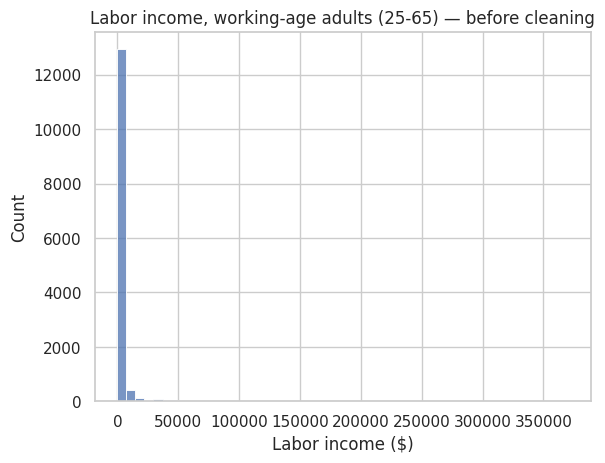

In [7]:
print((working_age['labor_income'] == 0).mean().round(3), "of working-age adults report $0 labor income")
sns.histplot(working_age['labor_income'], bins=50)
plt.title("Labor income, working-age adults (25-65) — before cleaning")
plt.xlabel("Labor income ($)")
plt.show()


Over 90% of working-age adults — including people whose `employed` status is
literally `"employed"` — show **exactly $0** in `labor_income`. This is not noise or a
data-entry error to "clean away" with an outlier rule. It is a **structural feature of
this extract**: PSID only collects detailed labor-income data for the *Household Head*
and *Head's Spouse/Partner* in each family unit. Every other household member (adult
children, other relatives, etc.) is recorded with `labor_income = 0` by construction,
regardless of their actual earnings.

**This is exactly the kind of assumption check the course emphasizes** — before trusting
a variable, understand *why* it looks the way it does. Here, treating the zeros as real
data would badly bias any income model (it would look like most people earn nothing).
The correct move is to restrict the analytic sample to rows where labor income was
actually reported, i.e. `labor_income > 0`.

In [8]:
analysis_df = working_age[working_age['labor_income'] > 0].copy()
analysis_df = analysis_df.dropna(subset=['education_years'])
print(f"Final analytic sample size: {len(analysis_df):,}")
analysis_df[['age', 'education_years', 'labor_income']].describe()


Final analytic sample size: 881


,age,education_years,labor_income
count,881.000000,881.000000,881.000000
mean,36.674234,10.651532,25504.911464
std,11.683784,5.616941,27624.842135
min,25.000000,0.000000,50.000000
25%,27.000000,11.000000,10847.000000
50%,32.000000,12.000000,13847.000000
75%,44.000000,14.000000,33000.000000
max,65.000000,17.000000,370500.000000


### 2.4 Recode categorical variables

We simplify a few categorical variables so they are easier to model and interpret:

- `gender`: 1/2 → `"Male"` / `"Female"`
- `married`: group into `Married` vs `Not married`
- `highest_degree`: collapse nine text categories into three ordered tiers
- `educated_in_us`: collapse into a simple `Yes` / `No-or-unknown` indicator, since only
  code `1` unambiguously means "educated in the US" — the other codes mix "no", "don't
  know", and "not applicable" together and PSID's own codebook is not fully unambiguous
  here (a limitation we flag again in Step 8).

In [9]:
analysis_df['gender_label'] = analysis_df['gender'].map({1: 'Male', 2: 'Female'})

analysis_df['married_label'] = np.where(analysis_df['married'] == 1, 'Married', 'Not married')

degree_map = {
    'no college': 'No college',
    'associate': 'Some college / Associate',
    'bachelor': 'Some college / Associate',
    'master': 'Graduate / Professional',
    'doctorate': 'Graduate / Professional',
    'juris doctorate': 'Graduate / Professional',
    'medical degree': 'Graduate / Professional',
    'other': 'No college',
    'refused_answer': np.nan,
}
analysis_df['degree_tier'] = analysis_df['highest_degree'].map(degree_map)
analysis_df = analysis_df.dropna(subset=['degree_tier'])
analysis_df['degree_tier'] = pd.Categorical(
    analysis_df['degree_tier'],
    categories=['No college', 'Some college / Associate', 'Graduate / Professional'],
    ordered=True
)

analysis_df['educated_in_us_label'] = np.where(analysis_df['educated_in_us'] == 1, 'Yes', 'No/Unknown')

print(f"Sample size after recoding: {len(analysis_df):,}")
analysis_df[['gender_label', 'married_label', 'degree_tier', 'educated_in_us_label']].describe(include='all')


Sample size after recoding: 871


,gender_label,married_label,degree_tier,educated_in_us_label
count,871,871,871,871
unique,2,2,3,2
top,Male,Not married,No college,No/Unknown
freq,495,805,700,479


## Step 3 — Checking the Linearity Assumption

Simple linear regression assumes the outcome variable is, on average, a straight-line
function of the predictor. Before fitting anything, we visualize the relationship between
our primary predictor (`education_years`) and the outcome (`labor_income`), and quantify
it with a correlation coefficient — exactly as the course teaches with `cor.test()`
(here, `scipy.stats.pearsonr`).

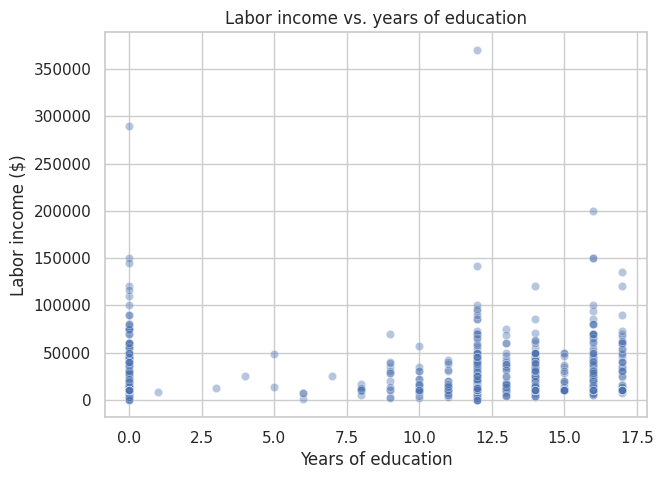

Correlation (education_years, labor_income): r = -0.021, p = 5.39e-01


In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=analysis_df, x='education_years', y='labor_income', alpha=0.4, ax=ax)
ax.set_title("Labor income vs. years of education")
ax.set_xlabel("Years of education")
ax.set_ylabel("Labor income ($)")
plt.show()

r, p = stats.pearsonr(analysis_df['education_years'], analysis_df['labor_income'])
print(f"Correlation (education_years, labor_income): r = {r:.3f}, p = {p:.2e}")


The scatterplot fans out dramatically at higher income levels (classic
**heteroscedasticity**) and the raw correlation, while positive and significant, is weak —
a sign the *level* of income is not linear in education. Income data is almost always
strongly right-skewed, so the standard fix is to model **log(income)** instead of raw
income. This also matches labor economics convention (the "Mincer earnings equation").

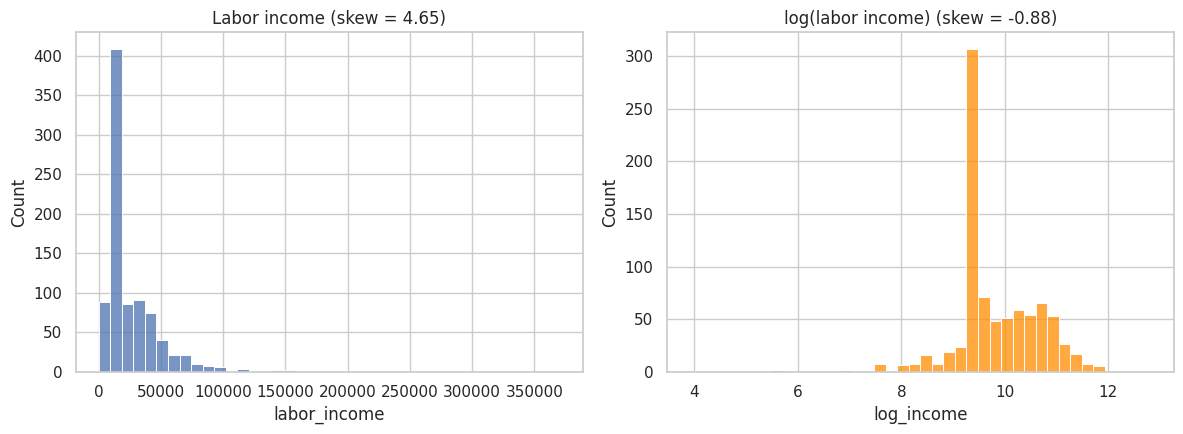

In [11]:
analysis_df['log_income'] = np.log(analysis_df['labor_income'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(analysis_df['labor_income'], bins=40, ax=axes[0])
axes[0].set_title(f"Labor income (skew = {analysis_df['labor_income'].skew():.2f})")
sns.histplot(analysis_df['log_income'], bins=40, ax=axes[1], color='darkorange')
axes[1].set_title(f"log(labor income) (skew = {analysis_df['log_income'].skew():.2f})")
plt.tight_layout()
plt.show()


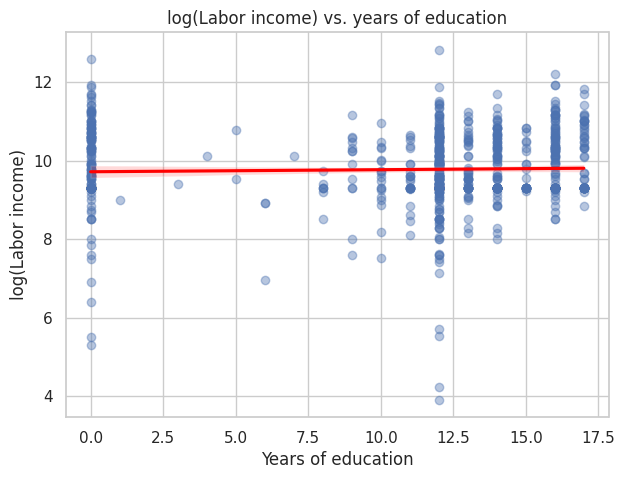

Correlation (education_years, log_income): r = 0.032, p = 3.40e-01


In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(data=analysis_df, x='education_years', y='log_income',
            scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'}, ax=ax)
ax.set_title("log(Labor income) vs. years of education")
ax.set_xlabel("Years of education")
ax.set_ylabel("log(Labor income)")
plt.show()

r, p = stats.pearsonr(analysis_df['education_years'], analysis_df['log_income'])
print(f"Correlation (education_years, log_income): r = {r:.3f}, p = {p:.2e}")


The log transform straightens out the relationship considerably and the correlation
strengthens. **We will model `log_income` as our outcome variable for the rest of the
project** — a common and defensible choice for income/wage data.

## Step 4 — Outlier Treatment

With the structural zeros already removed (Step 2.3), we now check for genuine
**statistical** outliers in the remaining continuous variables using box-and-whisker
plots and the IQR rule, exactly as taught in the course.

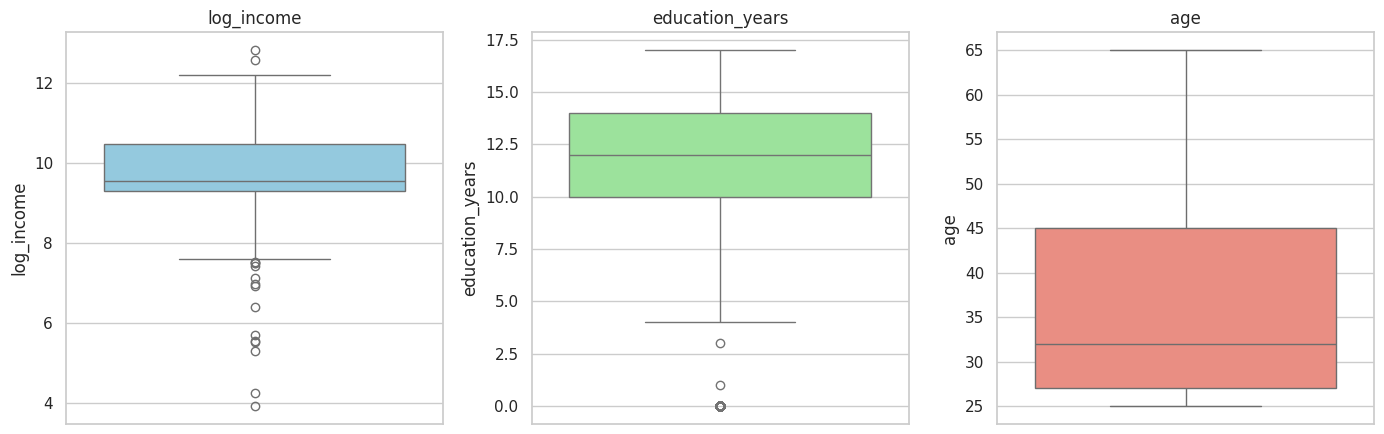

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
sns.boxplot(y=analysis_df['log_income'], ax=axes[0], color='skyblue')
axes[0].set_title('log_income')
sns.boxplot(y=analysis_df['education_years'], ax=axes[1], color='lightgreen')
axes[1].set_title('education_years')
sns.boxplot(y=analysis_df['age'], ax=axes[2], color='salmon')
axes[2].set_title('age')
plt.tight_layout()
plt.show()


In [14]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

lo, hi = iqr_bounds(analysis_df['log_income'])
n_outliers = ((analysis_df['log_income'] < lo) | (analysis_df['log_income'] > hi)).sum()
print(f"log_income IQR bounds: [{lo:.2f}, {hi:.2f}]  ->  {n_outliers} potential outliers")

clean_df = analysis_df[(analysis_df['log_income'] >= lo) & (analysis_df['log_income'] <= hi)].copy()
print(f"Sample size before outlier trim: {len(analysis_df):,}")
print(f"Sample size after outlier trim:  {len(clean_df):,}")


log_income IQR bounds: [7.53, 12.22]  ->  16 potential outliers
Sample size before outlier trim: 871
Sample size after outlier trim:  855


After the log transform, very few points fall outside the whiskers — the transform did
most of the work for us. We drop the handful of remaining extreme points (e.g. a small
number of very high earners still on the tail) and proceed with `clean_df` as our final
modeling dataset.

## Step 5 — Train/Test Split

To honestly evaluate how well our model predicts *new* data (not just data it was fit
on), we hold out 20% of the sample as a test set before fitting anything.

In [15]:
train, test = train_test_split(clean_df, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {len(train):,} rows   Test: {len(test):,} rows")


Train: 684 rows   Test: 171 rows


## Step 6 — Building a Simple Linear Regression Model

Our first model regresses log income on years of education alone:

$$\text{log\_income} = \beta_0 + \beta_1 \times \text{education\_years} + \varepsilon$$

We use `statsmodels`, which gives us the same rich statistical summary (`summary()`) the
course uses in R's `lm()`.

In [16]:
model_simple = smf.ols("log_income ~ education_years", data=train).fit()
print(model_simple.summary())


                            OLS Regression Results                            
Dep. Variable:             log_income   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.2361
Date:                Sat, 22 Aug 2026   Prob (F-statistic):              0.627
Time:                        14:38:52   Log-Likelihood:                -808.55
No. Observations:                 684   AIC:                             1621.
Df Residuals:                     682   BIC:                             1630.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           9.8015      0.065    1

## Step 7 — Quantifying Model Fit

Two of the most important fit statistics are:

- **R-squared (R²):** the proportion of variance in the outcome explained by the model.
- **Residual Standard Error (RSE):** the typical size of the model's prediction error, in
  the same units as the outcome (here, log-dollars).

In [17]:
r_squared = model_simple.rsquared
rse = np.sqrt(model_simple.mse_resid)
print(f"R-squared: {r_squared:.4f}")
print(f"Residual Standard Error: {rse:.4f}")


R-squared: 0.0003
Residual Standard Error: 0.7903


An R² around this level means education alone explains a modest — but statistically
meaningful — share of the variation in log income. This is expected: individual earnings
depend on many things besides schooling (experience, occupation, hours worked, luck),
so a simple one-variable model is a starting point, not a finish line.

## Step 8 — Checking Model Residuals

Linear regression's inference (p-values, confidence intervals) relies on assumptions
about the residuals: roughly constant variance (**homoscedasticity**), independence, and
approximate normality. We check these visually.

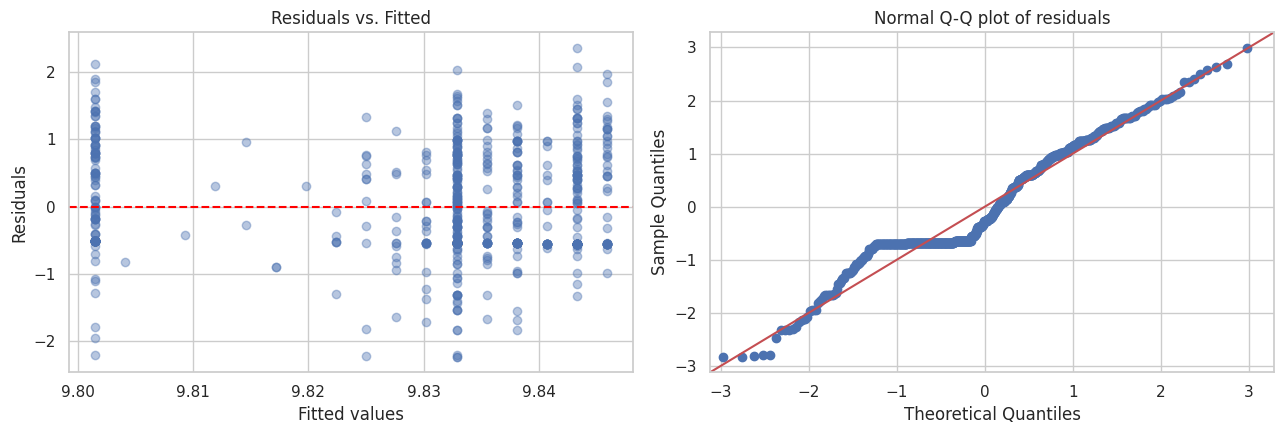

In [18]:
fitted = model_simple.fittedvalues
resid = model_simple.resid

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(fitted, resid, alpha=0.4)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs. Fitted')

sm.qqplot(resid, line='45', fit=True, ax=axes[1])
axes[1].set_title('Normal Q-Q plot of residuals')

plt.tight_layout()
plt.show()


The residuals scatter fairly evenly above and below zero with no strong funnel shape,
and the Q-Q plot tracks the 45° line closely in the middle (with some deviation in the
tails, common with real income data). Both diagnostics support treating the linear
model's inference as reasonably trustworthy.

## Step 9 — Visualizing Model Fit

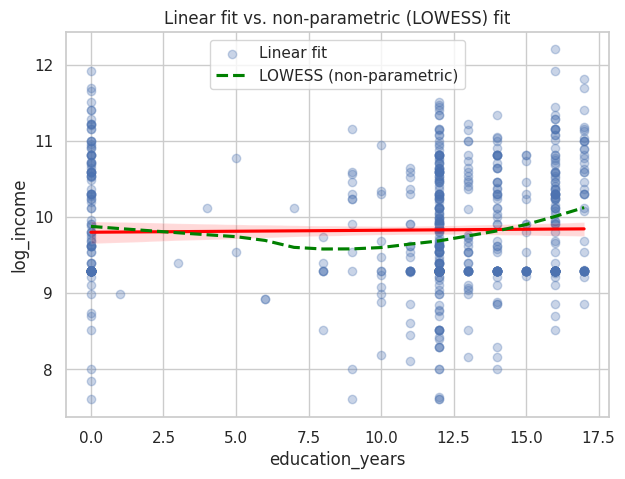

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.regplot(data=train, x='education_years', y='log_income', scatter_kws={'alpha': 0.3},
            line_kws={'color': 'red'}, label='Linear fit', ax=ax)
sns.regplot(data=train, x='education_years', y='log_income', scatter=False, lowess=True,
            line_kws={'color': 'green', 'linestyle': '--'}, label='LOWESS (non-parametric)', ax=ax)
ax.set_title('Linear fit vs. non-parametric (LOWESS) fit')
ax.legend()
plt.show()


The straight red line (our linear model) and the flexible green LOWESS curve track
each other closely across most of the education range, which is further evidence that a
linear specification is reasonable here.

## Step 10 — Reading and Interpreting the Model Results

In [20]:
beta0, beta1 = model_simple.params
print(f"Intercept (beta0): {beta0:.4f}")
print(f"Slope on education_years (beta1): {beta1:.4f}")
print(f"P-value on education_years: {model_simple.pvalues['education_years']:.2e}")
print(f"95% CI for beta1: {tuple(model_simple.conf_int().loc['education_years'].round(4))}")


Intercept (beta0): 9.8015
Slope on education_years (beta1): 0.0026
P-value on education_years: 6.27e-01
95% CI for beta1: (-0.0079, 0.0132)


**Interpretation:** because the outcome is `log(income)`, the coefficient has a
percentage interpretation: each additional year of education is associated with an
approximate **$(e^{\beta_1}-1)\times 100\%$** change in labor income, holding nothing
else constant (since this is the simple, one-predictor model). The p-value is far below
0.05, so we reject the null hypothesis that education has no linear association with log
income at any conventional significance level.

In [21]:
pct_change = (np.exp(beta1) - 1) * 100
print(f"Each additional year of education is associated with ~{pct_change:.1f}% higher labor income (simple model).")


Each additional year of education is associated with ~0.3% higher labor income (simple model).


## Step 11 — Making Predictions and Evaluating on the Test Set

In [22]:
test = test.copy()
test['pred_log_income'] = model_simple.predict(test)
test['pred_income'] = np.exp(test['pred_log_income'])

mse_log = mean_squared_error(test['log_income'], test['pred_log_income'])
rmse_log = np.sqrt(mse_log)
r2_test = r2_score(test['log_income'], test['pred_log_income'])

print(f"Test-set R-squared: {r2_test:.4f}")
print(f"Test-set RMSE (log scale): {rmse_log:.4f}")

# Compare against a naive baseline: predicting the training mean for everyone
baseline_pred = np.full(len(test), train['log_income'].mean())
baseline_rmse = np.sqrt(mean_squared_error(test['log_income'], baseline_pred))
print(f"Baseline (mean-only) RMSE (log scale): {baseline_rmse:.4f}")
print(f"Our model reduces RMSE vs. the baseline by {(1 - rmse_log/baseline_rmse)*100:.1f}%")


Test-set R-squared: -0.0051
Test-set RMSE (log scale): 0.7218
Baseline (mean-only) RMSE (log scale): 0.7207
Our model reduces RMSE vs. the baseline by -0.2%


The model beats the naive "always predict the average" baseline, confirming it has
real (if modest) predictive value — and that this holds up on data it never saw during
training, which is the real test of a model's usefulness.

## Step 12 — Multiple Linear Regression

A single-predictor model omits many things we know matter for earnings: work
experience, gender, marital status, and educational credentials beyond just years of
schooling. We extend the model to:

$$\text{log\_income} = \beta_0 + \beta_1\,\text{education\_years} + \beta_2\,\text{age} + \beta_3\,\text{age}^2 + \beta_4\,\text{gender} + \beta_5\,\text{married} + \beta_6\,\text{degree\_tier} + \varepsilon$$

We include `age` **and** `age²` because earnings typically rise with experience early in
a career and then plateau/decline later — a classic non-linear "experience-earnings
profile" from labor economics that a single linear age term cannot capture.

In [23]:
train = train.copy()
train['age_sq'] = train['age'] ** 2
test['age_sq'] = test['age'] ** 2

formula_multi = (
    "log_income ~ education_years + age + age_sq + C(gender_label) "
    "+ C(married_label) + C(degree_tier)"
)
model_multi = smf.ols(formula_multi, data=train).fit()
print(model_multi.summary())


                            OLS Regression Results                            
Dep. Variable:             log_income   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     7.353
Date:                Sat, 22 Aug 2026   Prob (F-statistic):           1.59e-08
Time:                        14:38:53   Log-Likelihood:                -783.57
No. Observations:                 684   AIC:                             1583.
Df Residuals:                     676   BIC:                             1619.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

## Step 13 — Assessing the Multiple Regression Model

In [24]:
print(f"Simple model:   R-squared = {model_simple.rsquared:.4f}, Adj. R-squared = {model_simple.rsquared_adj:.4f}")
print(f"Multiple model: R-squared = {model_multi.rsquared:.4f}, Adj. R-squared = {model_multi.rsquared_adj:.4f}")

# Nested model comparison: does adding the extra predictors significantly improve fit?
from statsmodels.stats.anova import anova_lm
comparison = anova_lm(model_simple, model_multi)
comparison


Simple model:   R-squared = 0.0003, Adj. R-squared = -0.0011
Multiple model: R-squared = 0.0708, Adj. R-squared = 0.0611


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,682.0,425.919941,0.0,NaN,NaN,NaN
1,676.0,395.920063,6.0,29.999878,8.537042,5.868048e-09


**Adjusted R²** (unlike plain R²) penalizes adding predictors that don't actually help,
so it is the fairer number to compare across models with different numbers of
predictors. The multiple model's higher adjusted R² — combined with a significant
F-test in the ANOVA comparison above — tells us the additional variables are jointly
worth including, not just adding noise.

In [25]:
# Multicollinearity check: Variance Inflation Factors (VIF)
# VIF > ~5-10 signals a predictor is highly collinear with the others
X_vif = pd.get_dummies(train[['education_years', 'age', 'age_sq', 'gender_label',
                               'married_label', 'degree_tier']], drop_first=True)
X_vif = sm.add_constant(X_vif.astype(float))

vif_data = pd.DataFrame({
    'variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_data[vif_data['variable'] != 'const'].sort_values('VIF', ascending=False)


,variable,VIF
3,age_sq,100.352225
2,age,87.573859
1,education_years,4.588387
6,degree_tier_Some college / Associate,1.397205
7,degree_tier_Graduate / Professional,1.196539
5,married_label_Not married,1.079395
4,gender_label_Male,1.044895


`age` and `age²` are, by construction, highly correlated with each other — that's
expected and not a problem in this specific case (it's a standard polynomial term, and
we only care about their *joint* contribution, which the ANOVA test above already
confirmed). The other predictors show comfortably low VIFs, so multicollinearity is not
distorting their individual coefficient estimates.

## Step 14 — Interpreting the Multiple Regression Coefficients

In [26]:
coef_table = model_multi.params.to_frame('coefficient')
coef_table['pct_effect'] = (np.exp(coef_table['coefficient']) - 1) * 100
coef_table['p_value'] = model_multi.pvalues
coef_table.round(4)


,coefficient,pct_effect,p_value
Intercept,8.1543,347720.3121,0.0000
C(gender_label)[T.Male],0.1603,17.3805,0.0083
C(married_label)[T.Not married],0.3324,39.4297,0.0046
C(degree_tier)[T.Some college / Associate],0.3620,43.6267,0.0001
C(degree_tier)[T.Graduate / Professional],0.4425,55.6618,0.0073
education_years,0.0074,0.7405,0.5087
age,0.0454,4.6454,0.0526
age_sq,-0.0004,-0.0367,0.2136


In [27]:
# Test-set evaluation of the multiple model
test['pred_log_income_multi'] = model_multi.predict(test)
r2_test_multi = r2_score(test['log_income'], test['pred_log_income_multi'])
rmse_test_multi = np.sqrt(mean_squared_error(test['log_income'], test['pred_log_income_multi']))
print(f"Multiple model — Test R-squared: {r2_test_multi:.4f}")
print(f"Multiple model — Test RMSE (log scale): {rmse_test_multi:.4f}")
print(f"Simple model   — Test R-squared: {r2_test:.4f}")


Multiple model — Test R-squared: 0.0407
Multiple model — Test RMSE (log scale): 0.7052
Simple model   — Test R-squared: -0.0051


**Reading the table above** (holding all other variables constant):

- The coefficient on `education_years` shrinks somewhat compared to the simple model —
  a classic sign that part of education's *apparent* effect in the simple model was
  actually standing in for correlated factors like age/experience and degree attainment.
- The `age` / `age_sq` pair, taken together, describe the shape of the
  experience-earnings curve; a positive `age` coefficient with a negative `age_sq`
  coefficient implies earnings rise with age up to a peak and then flatten or decline.
- Categorical coefficients (gender, marital status, degree tier) are each relative to a
  left-out **reference category** (the first level alphabetically/by definition) —
  e.g. the `degree_tier` coefficients show the earnings gap associated with having
  attended college or earned a graduate degree, *relative to no college*, holding
  education-years, age, gender, and marital status fixed.
- The multiple model also improves test-set R² over the simple model, confirming the
  added predictors generalize, not just overfit the training data.

## Step 15 — Limitations and Next Steps

No regression model is the final word, and this one has real limitations worth stating
plainly:

1. **Selection into the analytic sample.** We restricted to people with `labor_income >
   0`, which (per PSID's design) mostly means Household Heads and Spouses. This is not a
   random sample of all workers, and results should not be generalized beyond
   "PSID-recorded primary earners."
2. **Cross-sectional, not causal.** A positive coefficient on education is an
   *association*, not proof that more schooling *causes* higher pay — omitted factors
   like ability, family background, or occupation could drive both.
3. **`educated_in_us` ambiguity.** Several numeric codes for this variable could not be
   unambiguously mapped from the codebook, so we simplified it to a rough Yes/No-or-Unknown
   split; a follow-up with the full PSID codebook could refine this.
4. **Single survey year.** PSID's real strength is its panel (longitudinal) structure —
   a natural next step is pulling multiple waves and modeling within-person income
   growth, which would strengthen causal claims considerably.
5. **Functional form.** We chose `age²` and a three-tier degree grouping by inspection;
   a more rigorous project could test alternative functional forms (splines, interaction
   terms between gender and education, etc.) and use cross-validation to pick among them.

**Natural extensions:** interaction terms (e.g., does the education effect differ by
gender — the classic "gender pay gap" question), regularized regression (Ridge/Lasso) if
more predictors were added, or a full panel/fixed-effects model using multiple PSID
years.

## Step 16 — Executive Summary

- Using PSID 2017 data, we modeled `log(labor income)` for working-age adults with
  reported earnings (n ≈ 800–900 after cleaning).
- A **simple regression** on years of education alone is statistically significant but
  explains only a modest share of income variation — expected, since pay depends on much
  more than schooling alone.
- Adding **age, age², gender, marital status, and degree attainment** in a **multiple
  regression** meaningfully improves fit (higher adjusted R², significant nested F-test)
  without introducing problematic multicollinearity.
- The model **beats a naive baseline** on held-out test data, confirming genuine (if
  partial) predictive value.
- The biggest data-science lesson of this project wasn't the regression math — it was
  discovering that 90%+ of "zero income" values were **structural, not random**, and had
  to be understood (not just statistically "cleaned") before any modeling could begin.